In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools
import os
import sys
import pandas as pd

import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Configurar pandas para mostrar todas las filas y columnas sin cortes
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

sys.path.append(os.getcwd())

script_dir = os.getcwd()
print(f"script_dir: {script_dir}")

# Configurar la fuente del texto
mpl.rc('font', family='serif', serif='cmr10', size=12)
plt.rcParams['axes.unicode_minus'] = False

# Configurar la fuente de MathText para que use Computer Modern
mpl.rcParams['mathtext.fontset'] = 'cm'  # Usa las fuentes de Computer Modern para las ecuaciones
mpl.rcParams['mathtext.rm'] = 'serif'    # Usa 'serif' para el modo matemático normal
mpl.rcParams['mathtext.it'] = 'serif:italic'  # Itálica para símbolos matemáticos
mpl.rcParams['mathtext.bf'] = 'serif:bold'    # Negrita para símbolos matemáticos




script_dir: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images


In [2]:
# Load the data
Svc = 'FR'
file_path = f'One_year_{Svc}.csv'

input_file_path = os.path.join(script_dir, file_path)
print(f"input_file_path: {input_file_path}")

df_operation = pd.read_csv(input_file_path, delimiter=',')
print(f"df_operation.shape: {df_operation.shape}")
print(f"df_operation: \n{df_operation.head(7440)}")


input_file_path: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images\One_year_FR.csv
df_operation.shape: (87600, 27)
df_operation: 
       hr   Col_SoC    P_BESS_t  name_policy  P_3f_cb_302  P_3f_cb_302_BESS_0  DSS_Total_Looses  switch_FR     P_bid_h  switch_PS     PS_peak  SW_FR_SoCmin  SW_FR_SoCmax  DSS_Total_Looses_BESS          f4_t           ISV           ICV  m_p_I2_I1  m_p_I2_I1_BESS  m_p_I0_I1  m_p_I0_I1_BESS  m_p_Normal  m_p_Normal_BESS          f3_t       f_i_1_t       f_i_2_t       f_i_3_t
0       0  0.472236 -499.760021            4  -219.202148          280.454397       7641.994965        1.0  500.000000        0.0  280.454397           0.0           0.0            6392.503643  9.328754e-02  1.164511e-03 -8.313542e-04  10.071963        8.914416  10.154903        9.035091    1.180116         1.185605 -1.635033e-01 -1.149277e-01 -1.102731e-01  4.651260e-03
1       0  0.444458 -500.000000            4  -219.442067          280.427

In [3]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

# Supongamos que tienes un dataframe llamado df_info_STK
# Seleccionar solo las columnas 'hr' y 'name_policy'
df_operation = df_operation[['Col_SoC','hr', 'name_policy']]

# Crear un índice de tiempo desde las 00:00 del 1 de enero de 2018
start_time = pd.to_datetime('2018-01-01 00:00:00')
time_index = pd.date_range(start=start_time, periods=87600, freq='6min')

# Crear una nueva columna 'datetime' en el DataFrame
df_operation['datetime'] = time_index

# Si deseas extraer las horas y minutos, puedes hacerlo de la siguiente manera
df_operation['hour'] = df_operation['datetime'].dt.hour
df_operation['minute'] = df_operation['datetime'].dt.minute

# Imprimir las primeras 5 filas y las últimas 5 filas
print(f"df_operation:\n{df_operation.head()}")



df_operation:
    Col_SoC  hr  name_policy            datetime  hour  minute
0  0.472236   0            4 2018-01-01 00:00:00     0       0
1  0.444458   0            4 2018-01-01 00:06:00     0       6
2  0.446420   0            4 2018-01-01 00:12:00     0      12
3  0.452611   0            4 2018-01-01 00:18:00     0      18
4  0.472637   0            4 2018-01-01 00:24:00     0      24


df_january: 
        Col_SoC    hr  name_policy            datetime  hour  minute  day  month
43440  0.342157  4344            4 2018-07-01 00:00:00     0       0    1      7
43441  0.344243  4344            4 2018-07-01 00:06:00     0       6    1      7
43442  0.316466  4344            4 2018-07-01 00:12:00     0      12    1      7
43443  0.308028  4344            4 2018-07-01 00:18:00     0      18    1      7
43444  0.314399  4344            4 2018-07-01 00:24:00     0      24    1      7
43445  0.299697  4344            4 2018-07-01 00:30:00     0      30    1      7
43446  0.310957  4344            4 2018-07-01 00:36:00     0      36    1      7
43447  0.315571  4344            4 2018-07-01 00:42:00     0      42    1      7
43448  0.306757  4344            4 2018-07-01 00:48:00     0      48    1      7
43449  0.313328  4344            4 2018-07-01 00:54:00     0      54    1      7
43450  0.293619  4345            4 2018-07-01 01:00:00     1       0    1      7
43451  0.303404

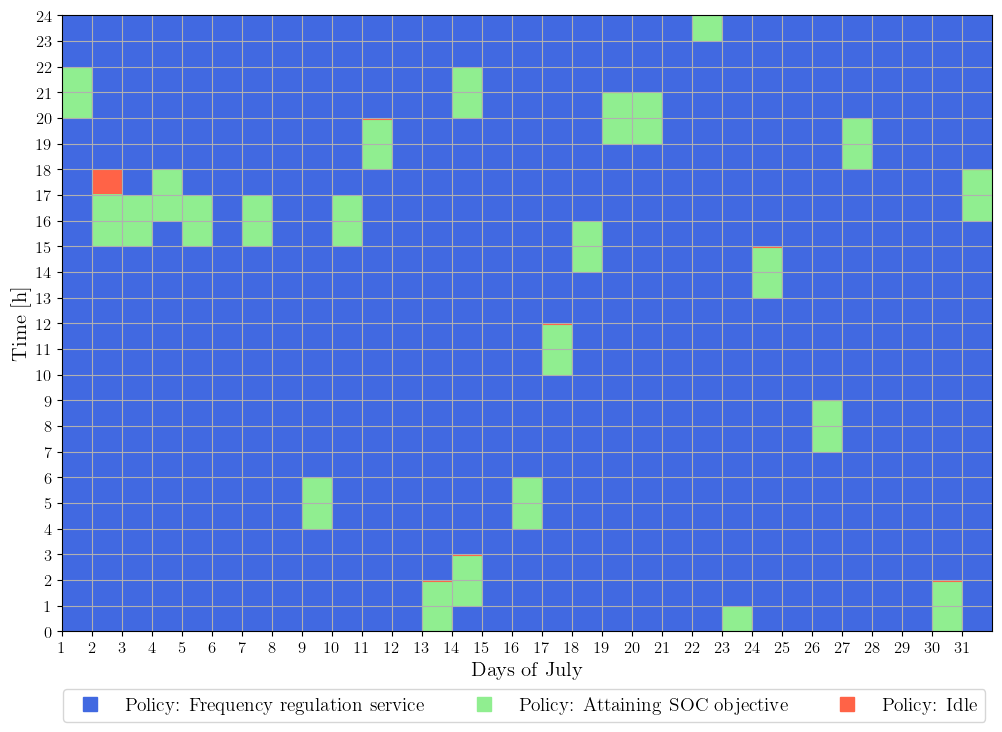

Gráfico PDF guardado en: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images\FR_Fig_08_Monthly_Operation\FR_Fig_08_Monthly_Operation_500kW_2000kWh_4657to4824_20260428_115552.pdf
Existe PDF?: True
Gráfico SVG guardado en: c:\Users\hgvillanueva\OneDrive - Universidad Pontificia Comillas\Codes\68__FR_PS_STK_SEGAN_images\FR_Fig_08_Monthly_Operation\FR_Fig_08_Monthly_Operation_500kW_2000kWh_4657to4824_20260428_115552.svg
Existe SVG?: True


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors
import os
import matplotlib.lines as mlines
import calendar

# Definir los colores según las políticas
colors_dict = {
    1: 'yellowgreen',     # Daily BESS Charging
    2: 'tomato',           # BESS Idle
    3: 'darkorange',       # PS
    4: 'royalblue',        # FR
    5: 'lightgreen'        # BESS SoC Objective Charging
}

# Filtrar solo los datos del primer mes (enero)
df_operation['day'] = df_operation['datetime'].dt.day
df_operation['month'] = df_operation['datetime'].dt.month

e_Month =  7
n_e_Month = calendar.month_name[e_Month]

# Filtrar las filas solo para el mes de enero (mes 1)
df_january = df_operation[df_operation['month'] == e_Month]
print(f"df_january: \n{df_january}")

# Ordenar el DataFrame por fecha (más antigua a más reciente)
df_january = df_january.sort_values(by='datetime', ascending=True)

# Crear un gráfico de figura y eje
fig, ax = plt.subplots(figsize=(12, 8))

e_fontsize = 15

# Contar las ocurrencias sin cambiar el orden original
grouped = df_january.groupby(['day', 'hour', 'name_policy']).size().reset_index(name='count')

# Reordenar según el índice original
grouped = df_january[['day', 'hour', 'name_policy']].merge(grouped, on=['day', 'hour', 'name_policy'], how='left')


# Para cada hora y día, contar la frecuencia de cada política
for (day, hour), group in grouped.groupby(['day', 'hour']):
    total_count = group['count'].sum()  # Total de políticas en esta hora y día
    
    # Ya no ordenamos por frecuencia, solo por el índice (fecha)
    group = group.sort_index(ascending=True)  # Ordenar en orden descendente de fecha (anticronológico)

    # Coordenadas iniciales para apilar los rectángulos (en esta lógica no es necesario invertir el apilamiento)
    y_offset = 0  # Inicializar el offset en 0 para apilar hacia arriba
    
    # Iterar sobre las políticas ordenadas por su índice (fecha)
    for _, row in group.iterrows():
        policy = row['name_policy']
        count = row['count']
        
        # Obtener el color de la política
        policy_color = mcolors.to_rgba(colors_dict[policy])  # Usamos to_rgba para asegurar que el color sea adecuado
        
        # Proporción de esa política
        proportion = count / total_count
        
        # Dibujar el rectángulo correspondiente (hacia arriba)
        ax.add_patch(plt.Rectangle(
            (day, hour - 0.0 + y_offset),  # Ajuste de la posición, manteniendo las coordenadas
            1,  # Ancho del rectángulo (1 hora por día)
            proportion,  # Altura proporcional al número de ocurrencias
            color=policy_color,  # Color basado en la política
            lw=0.1  # Grosor de contorno
        ))

        # Actualizar el desplazamiento para el siguiente rectángulo
        y_offset += proportion  # Sumar para apilar hacia arriba

# Definir las líneas para la leyenda
legend_2 = mlines.Line2D([], [], color='royalblue', label='Policy: Frequency regulation service', linestyle='None', marker='s', markersize=10)
legend_4 = mlines.Line2D([], [], color='lightgreen', label='Policy: Attaining SOC objective', linestyle='None', marker='s', markersize=10)
legend_5 = mlines.Line2D([], [], color='tomato', label='Policy: Idle', linestyle='None', marker='s', markersize=10)

# Agregar la leyenda general
fig.legend(handles=[legend_2, legend_4, legend_5], loc='upper center', ncol=3, bbox_to_anchor=(0.51, 0.05), fontsize=e_fontsize-1)  # Ubicar debajo del gráfico

# Configuración de los ejes
ax.set_xlabel(f'Days of {n_e_Month}', fontsize=e_fontsize)
ax.set_ylabel('Time [h]', fontsize=e_fontsize)
ax.set_xticks(range(1, 32, 1))  # Días del mes (enero)
ax.set_yticks(range(0, 25, 1))  # Horas del día
ax.set_xlim(1, 32)  # Rango de días (1-31)
ax.set_ylim(-0, 24)  # Rango de horas (0-23)
ax.grid(True)

######## Save image
import time
from datetime import datetime

output_dir = os.path.join(script_dir, f'{Svc}_Fig_08_Monthly_Operation')
os.makedirs(output_dir, exist_ok=True)

now = datetime.now()
fecha_hora = now.strftime("%Y%m%d_%H%M%S")

primera_hora = 4657   # 14 de julio | 00 to 01
ultima_hora  = 4824   # 20 de julio | 23 to 24
P_BESS = 500
E_BESS = 2000

nombre_base = (
    f'{Svc}_Fig_08_Monthly_Operation_'
    f'{P_BESS}kW_{E_BESS}kWh_'
    f'{primera_hora}to{ultima_hora}_'
    f'{fecha_hora}'
)

# Paths
output_path_pdf = os.path.abspath(
    os.path.join(output_dir, f'{nombre_base}.pdf')
)

output_path_svg = os.path.abspath(
    os.path.join(output_dir, f'{nombre_base}.svg')
)

# Save exactly the same figure in both formats
fig.savefig(output_path_pdf, bbox_inches='tight', dpi=300)
fig.savefig(output_path_svg, bbox_inches='tight', dpi=300)

plt.show()

print(f"Gráfico PDF guardado en: {output_path_pdf}")
print(f"Existe PDF?: {os.path.exists(output_path_pdf)}")

print(f"Gráfico SVG guardado en: {output_path_svg}")
print(f"Existe SVG?: {os.path.exists(output_path_svg)}")
